# Hotel Booking Analysis

## Project Objective

Analyze hotel booking data to understand booking patterns, cancellations, customer characteristics, and factors associated with cancellations.

## Import Libraries

In [70]:
import pandas as pd
import matplotlib.pyplot as plt

## Load Dataset

In [71]:
df = pd.read_csv("hotel_bookings.csv")

In [72]:
df.duplicated().sum()

np.int64(31994)

In [73]:
df = df.drop_duplicates()

In [74]:
df.shape

(87396, 32)

**Data Cleaning Note:** The original dataset contained 31,994 exact duplicate rows, which were removed before further cleaning and analysis to reduce the risk of double-counting. This assumes that identical rows represent redundant records. However, identical records may sometimes represent legitimate separate bookings, so this assumption should be considered when interpreting the results.

## Initial Data Understanding

In [75]:
df.head()

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,...,No Deposit,NaN,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,...,No Deposit,304.0,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,...,No Deposit,240.0,NaN,0,Transient,98.0,0,1,Check-Out,2015-07-03


In [76]:
df.shape

(87396, 32)

In [77]:
df.columns

Index(['hotel', 'is_canceled', 'lead_time', 'arrival_date_year',
       'arrival_date_month', 'arrival_date_week_number',
       'arrival_date_day_of_month', 'stays_in_weekend_nights',
       'stays_in_week_nights', 'adults', 'children', 'babies', 'meal',
       'country', 'market_segment', 'distribution_channel',
       'is_repeated_guest', 'previous_cancellations',
       'previous_bookings_not_canceled', 'reserved_room_type',
       'assigned_room_type', 'booking_changes', 'deposit_type', 'agent',
       'company', 'days_in_waiting_list', 'customer_type', 'adr',
       'required_car_parking_spaces', 'total_of_special_requests',
       'reservation_status', 'reservation_status_date'],
      dtype='object')

In [78]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 87396 entries, 0 to 119389
Data columns (total 32 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   hotel                           87396 non-null  object 
 1   is_canceled                     87396 non-null  int64  
 2   lead_time                       87396 non-null  int64  
 3   arrival_date_year               87396 non-null  int64  
 4   arrival_date_month              87396 non-null  object 
 5   arrival_date_week_number        87396 non-null  int64  
 6   arrival_date_day_of_month       87396 non-null  int64  
 7   stays_in_weekend_nights         87396 non-null  int64  
 8   stays_in_week_nights            87396 non-null  int64  
 9   adults                          87396 non-null  int64  
 10  children                        87392 non-null  float64
 11  babies                          87396 non-null  int64  
 12  meal                            8739

In [79]:
df.isnull().sum()

hotel                                 0
is_canceled                           0
lead_time                             0
arrival_date_year                     0
arrival_date_month                    0
arrival_date_week_number              0
arrival_date_day_of_month             0
stays_in_weekend_nights               0
stays_in_week_nights                  0
adults                                0
children                              4
babies                                0
meal                                  0
country                             452
market_segment                        0
distribution_channel                  0
is_repeated_guest                     0
previous_cancellations                0
previous_bookings_not_canceled        0
reserved_room_type                    0
assigned_room_type                    0
booking_changes                       0
deposit_type                          0
agent                             12193
company                           82137


## Data Cleaning

In [80]:
df["children"].value_counts(dropna = False)

children
0.0     79028
1.0      4695
2.0      3593
3.0        75
NaN         4
10.0        1
Name: count, dtype: int64

In [81]:
df["children"] = df["children"].fillna(0)

In [82]:
df["children"].isnull().sum()

np.int64(0)

**Missing Values in Children:** Four missing values were replaced with 0, assuming that no recorded children meant zero children. This assumption may not always hold, so it should be acknowledged as a limitation.

In [83]:
df["country"].value_counts(dropna = False).head(15)

country
PRT    27453
GBR    10433
FRA     8837
ESP     7252
DEU     5387
ITA     3066
IRL     3016
BEL     2081
BRA     1995
NLD     1911
USA     1875
CHE     1570
CN      1093
AUT      947
SWE      837
Name: count, dtype: int64

In [84]:
df["country"] = df["country"].fillna("Unknown")

In [85]:
df["country"].isnull().sum()

np.int64(0)

**Missing Values in Country:** Missing country values were replaced with "Unknown" because the actual countries could not be reliably inferred from the available data.

In [86]:
df["agent"].value_counts(dropna = False).head(15)

agent
9.0      28759
240.0    13028
NaN      12193
14.0      3349
7.0       3300
250.0     2779
241.0     1644
28.0      1502
8.0       1383
1.0       1232
6.0       1117
40.0       986
314.0      844
242.0      722
83.0       614
Name: count, dtype: int64

In [87]:
df["agent"] = df["agent"].fillna("Unknown")

In [88]:
df["agent"].isnull().sum()

np.int64(0)

**Missing Values in Agent:** Missing agent values were labelled "Unknown" to indicate that the agent information was not recorded. This avoids assuming that the booking was made without an agent.

In [89]:
df["company"].value_counts(dropna = False).head(15)

company
NaN      82137
40.0       851
223.0      503
45.0       238
153.0      206
154.0      133
219.0      131
174.0      121
281.0      119
233.0       95
51.0        80
405.0       77
94.0        76
47.0        62
331.0       60
Name: count, dtype: int64

In [90]:
df = df.drop(columns = ["company"])

In [91]:
df.columns

Index(['hotel', 'is_canceled', 'lead_time', 'arrival_date_year',
       'arrival_date_month', 'arrival_date_week_number',
       'arrival_date_day_of_month', 'stays_in_weekend_nights',
       'stays_in_week_nights', 'adults', 'children', 'babies', 'meal',
       'country', 'market_segment', 'distribution_channel',
       'is_repeated_guest', 'previous_cancellations',
       'previous_bookings_not_canceled', 'reserved_room_type',
       'assigned_room_type', 'booking_changes', 'deposit_type', 'agent',
       'days_in_waiting_list', 'customer_type', 'adr',
       'required_car_parking_spaces', 'total_of_special_requests',
       'reservation_status', 'reservation_status_date'],
      dtype='object')

In [92]:
df.isnull().sum()

hotel                             0
is_canceled                       0
lead_time                         0
arrival_date_year                 0
arrival_date_month                0
arrival_date_week_number          0
arrival_date_day_of_month         0
stays_in_weekend_nights           0
stays_in_week_nights              0
adults                            0
children                          0
babies                            0
meal                              0
country                           0
market_segment                    0
distribution_channel              0
is_repeated_guest                 0
previous_cancellations            0
previous_bookings_not_canceled    0
reserved_room_type                0
assigned_room_type                0
booking_changes                   0
deposit_type                      0
agent                             0
days_in_waiting_list              0
customer_type                     0
adr                               0
required_car_parking_spaces 

**Company Column Removal:** The `company` column was removed because a large proportion of its values were missing. Retaining this column could provide limited information for the analysis.

In [93]:
df["adults"].value_counts().sort_values()

adults
6         1
50        1
55        1
10        1
40        1
5         2
20        2
27        2
26        5
4        60
0       385
3      5935
1     16503
2     64497
Name: count, dtype: int64

In [94]:
df[df["adults"] == 0][["adults","children","babies","hotel","is_canceled"]]

,adults,children,babies,hotel,is_canceled
2224,0,0.0,0,Resort Hotel,0
2409,0,0.0,0,Resort Hotel,0
3181,0,0.0,0,Resort Hotel,0
3684,0,0.0,0,Resort Hotel,0
3708,0,0.0,0,Resort Hotel,0
...,...,...,...,...,...
117204,0,2.0,0,City Hotel,0
117274,0,2.0,0,City Hotel,0
117303,0,2.0,0,City Hotel,0
117453,0,2.0,0,City Hotel,0


In [95]:
df["total_guests"] = df["adults"] + df["children"] + df["babies"]

In [96]:
df["total_guests"].value_counts().sort_index().head()

total_guests
0.0      166
1.0    16072
2.0    57057
3.0    10078
4.0     3870
Name: count, dtype: int64

In [97]:
df[df["total_guests"] == 0][["hotel", "is_canceled", "adults", "children", "babies", "lead_time", "adr"]].head(10)

,hotel,is_canceled,adults,children,babies,lead_time,adr
2224,Resort Hotel,0,0,0.0,0,1,0.0
2409,Resort Hotel,0,0,0.0,0,0,0.0
3181,Resort Hotel,0,0,0.0,0,36,0.0
3684,Resort Hotel,0,0,0.0,0,165,0.0
3708,Resort Hotel,0,0,0.0,0,165,0.0
4127,Resort Hotel,1,0,0.0,0,0,0.0
9376,Resort Hotel,1,0,0.0,0,0,0.0
31765,Resort Hotel,0,0,0.0,0,31,28.0
32029,Resort Hotel,0,0,0.0,0,4,0.0
32827,Resort Hotel,0,0,0.0,0,46,0.0


In [98]:
df = df[df["total_guests"] > 0]

**Zero-Guest Records:** Records with zero adults, children, and babies were removed because they did not contain any recorded guests for guest-based analysis.

In [99]:
df.shape

(87230, 32)

In [100]:
df[["stays_in_weekend_nights", "stays_in_week_nights", "adr"]].describe()

,stays_in_weekend_nights,stays_in_week_nights,adr
count,87230.000000,87230.000000,87230.000000
mean,1.004609,2.623925,106.518031
std,1.027408,2.039830,54.891227
min,0.000000,0.000000,-6.380000
25%,0.000000,1.000000,72.250000
50%,1.000000,2.000000,98.200000
75%,2.000000,4.000000,134.100000
max,19.000000,50.000000,5400.000000


In [101]:
df[df["adr"] < 0][["hotel", "is_canceled", "adults", "children", "babies", "adr"]]

,hotel,is_canceled,adults,children,babies,adr
14969,Resort Hotel,0,2,0.0,0,-6.38


In [102]:
df = df[df["adr"] >= 0]

**Negative ADR:** One record with a negative average daily rate was removed because a negative room rate was not meaningful for this analysis. Records with an ADR of zero were retained because they may represent legitimate special arrangements.

In [103]:
df.shape

(87229, 32)

In [104]:
df[df["adr"] == 0][["hotel", "is_canceled", "adults", "children", "babies", "adr"]].head(10)

,hotel,is_canceled,adults,children,babies,adr
0,Resort Hotel,0,2,0.0,0,0.0
1,Resort Hotel,0,2,0.0,0,0.0
125,Resort Hotel,0,4,0.0,0,0.0
167,Resort Hotel,0,2,0.0,0,0.0
168,Resort Hotel,0,1,0.0,0,0.0
196,Resort Hotel,0,2,0.0,0,0.0
197,Resort Hotel,0,2,0.0,0,0.0
421,Resort Hotel,1,2,0.0,0,0.0
428,Resort Hotel,0,1,0.0,0,0.0
459,Resort Hotel,0,2,0.0,0,0.0


In [105]:
df["total_nights"] = df["stays_in_weekend_nights"] + df["stays_in_week_nights"]

In [106]:
df["total_nights"].describe()

count    87229.000000
mean         3.628461
std          2.742879
min          0.000000
25%          2.000000
50%          3.000000
75%          5.000000
max         69.000000
Name: total_nights, dtype: float64

In [107]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 87229 entries, 0 to 119389
Data columns (total 33 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   hotel                           87229 non-null  object 
 1   is_canceled                     87229 non-null  int64  
 2   lead_time                       87229 non-null  int64  
 3   arrival_date_year               87229 non-null  int64  
 4   arrival_date_month              87229 non-null  object 
 5   arrival_date_week_number        87229 non-null  int64  
 6   arrival_date_day_of_month       87229 non-null  int64  
 7   stays_in_weekend_nights         87229 non-null  int64  
 8   stays_in_week_nights            87229 non-null  int64  
 9   adults                          87229 non-null  int64  
 10  children                        87229 non-null  float64
 11  babies                          87229 non-null  int64  
 12  meal                            8722

In [108]:
df["children"] = df["children"].astype(int)
df["total_guests"] = df["total_guests"].astype(int)

In [109]:
df[["children", "total_guests"]].dtypes

children        int64
total_guests    int64
dtype: object

In [110]:
df = df.reset_index(drop = True)
df.index

RangeIndex(start=0, stop=87229, step=1)

In [111]:
df.describe()

,is_canceled,lead_time,arrival_date_year,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,is_repeated_guest,previous_cancellations,previous_bookings_not_canceled,booking_changes,days_in_waiting_list,adr,required_car_parking_spaces,total_of_special_requests,total_guests,total_nights
count,87229.000000,87229.000000,87229.000000,87229.000000,87229.000000,87229.000000,87229.000000,87229.000000,87229.000000,87229.000000,87229.000000,87229.000000,87229.000000,87229.000000,87229.000000,87229.000000,87229.000000,87229.000000,87229.000000,87229.000000
mean,0.275241,79.969700,2016.210343,26.835284,15.815956,1.004574,2.623887,1.879364,0.138899,0.010845,0.038554,0.030403,0.184033,0.268477,0.746300,106.519325,0.084307,0.698942,2.029107,3.628461
std,0.446638,86.058295,0.686063,13.669175,8.835520,1.027364,2.039810,0.621727,0.456267,0.113704,0.192530,0.369347,1.733033,0.710612,10.001058,54.890211,0.281660,0.832052,0.790146,2.742879
min,0.000000,0.000000,2015.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000
25%,0.000000,11.000000,2016.000000,16.000000,8.000000,0.000000,1.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,72.250000,0.000000,0.000000,2.000000,2.000000
50%,0.000000,49.000000,2016.000000,27.000000,16.000000,1.000000,2.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,98.200000,0.000000,0.000000,2.000000,3.000000
75%,1.000000,125.000000,2017.000000,37.000000,23.000000,2.000000,4.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,134.100000,0.000000,1.000000,2.000000,5.000000
max,1.000000,737.000000,2017.000000,53.000000,31.000000,19.000000,50.000000,55.000000,10.000000,10.000000,1.000000,26.000000,72.000000,18.000000,391.000000,5400.000000,8.000000,5.000000,55.000000,69.000000


## Exploratory Data Analysis

### Question 1: How are bookings distributed between City Hotel and Resort Hotel?

In [112]:
df["hotel"].value_counts()

hotel
City Hotel      53274
Resort Hotel    33955
Name: count, dtype: int64

In [113]:
hotel_percentage = df["hotel"].value_counts(normalize = True) * 100
hotel_percentage

hotel
City Hotel      61.073725
Resort Hotel    38.926275
Name: proportion, dtype: float64

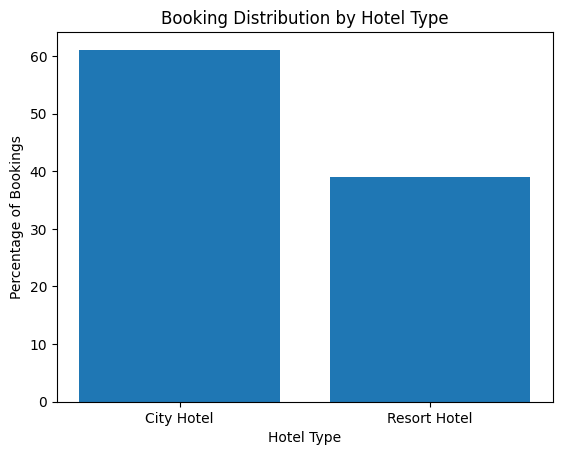

In [114]:
plt.bar(hotel_percentage.index,hotel_percentage.values)
plt.title("Booking Distribution by Hotel Type")
plt.xlabel("Hotel Type")
plt.ylabel("Percentage of Bookings")
plt.show()

**Insight:** City Hotel accounts for approximately 61% of all bookings, while Resort Hotel accounts for about 39%. This shows that City Hotel received considerably more bookings than Resort Hotel in the cleaned dataset.

### Question 2: What percentage of bookings are cancelled?

In [115]:
canceled_percentage = df["is_canceled"].value_counts(normalize = True) * 100
canceled_percentage

is_canceled
0    72.475897
1    27.524103
Name: proportion, dtype: float64

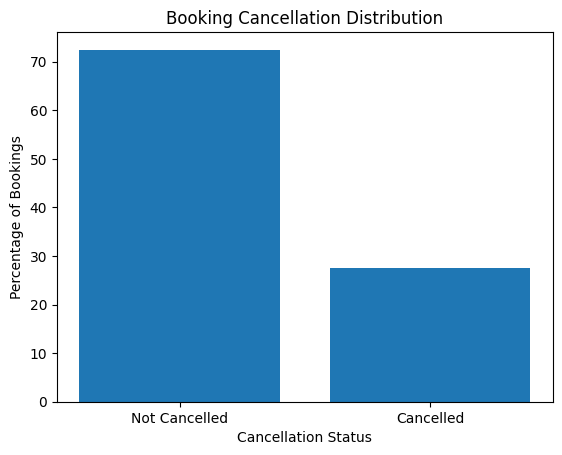

In [116]:
canceled_labels = ["Not Cancelled","Cancelled"]
plt.bar(canceled_labels, canceled_percentage.values)
plt.title("Booking Cancellation Distribution")
plt.xlabel("Cancellation Status")
plt.ylabel("Percentage of Bookings")
plt.show()

**Insight:** Approximately 27.5% of bookings were cancelled, while 72.5% were not cancelled. Although most bookings were not cancelled, the cancellation rate is significant enough to investigate which factors may be associated with cancellations.

### Question 3: Does lead time differ between cancelled and non-cancelled bookings?

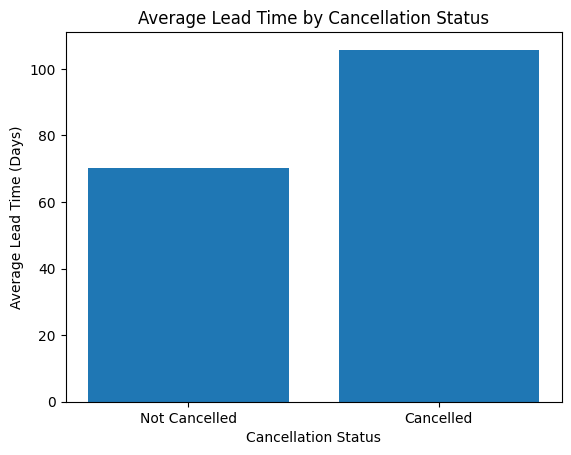

In [117]:
lead_time_by_cancellations = df.groupby("is_canceled")["lead_time"].mean()

lead_time_labels = ["Not Cancelled","Cancelled"]

plt.bar(lead_time_labels,lead_time_by_cancellations.values)
plt.title("Average Lead Time by Cancellation Status")
plt.xlabel("Cancellation Status")
plt.ylabel("Average Lead Time (Days)")
plt.show()

**Insight:** Cancelled bookings had a higher average lead time of approximately 106 days, compared with about 70 days for non-cancelled bookings. This suggests that bookings made further in advance were associated with a higher likelihood of cancellation.

### Question 4: How does the average length of stay vary between hotel types?

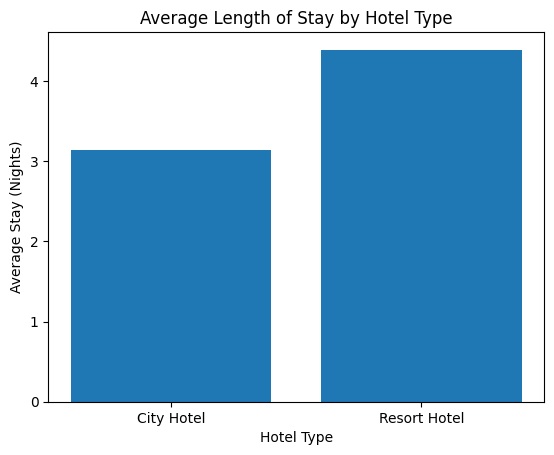

In [118]:
stay_length_by_hotel = df.groupby("hotel")["total_nights"].mean()

plt.bar(stay_length_by_hotel.index, stay_length_by_hotel.values)
plt.title("Average Length of Stay by Hotel Type")
plt.xlabel("Hotel Type")
plt.ylabel("Average Stay (Nights)")
plt.show()

**Insight:** The average length of stay is higher at Resort Hotels, at approximately 4.39 nights, compared with 3.14 nights at City Hotels. This indicates that guests at Resort Hotels tend to stay longer than guests at City Hotels.

### Question 5: Which countries contribute the most bookings? 

In [119]:
top_countries = df["country"].value_counts().head(10)
top_countries

country
PRT    27355
GBR    10423
FRA     8823
ESP     7244
DEU     5385
ITA     3061
IRL     3015
BEL     2081
BRA     1993
NLD     1910
Name: count, dtype: int64

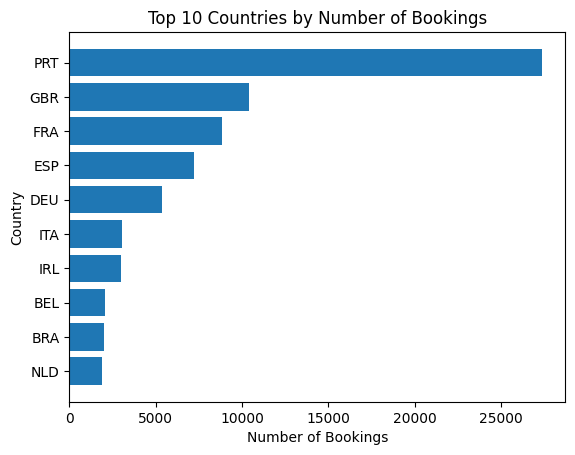

In [120]:
plt.barh(top_countries.index, top_countries.values)
plt.title("Top 10 Countries by Number of Bookings")
plt.xlabel("Number of Bookings")
plt.ylabel("Country")
plt.gca().invert_yaxis()
plt.show()

**Insight:** Portugal (PRT) contributed the highest number of bookings by a large margin, with 27,355 bookings, followed by the United Kingdom (GBR) with 10,423 bookings. Most of the top 10 booking countries are European, indicating that the dataset is strongly concentrated among European customers.

### Question 6: Are repeated guests less likely to cancel?

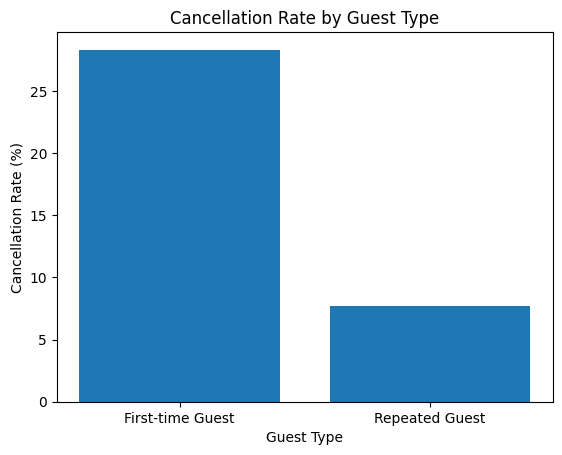

In [121]:
cancellation_by_guest_type = df.groupby("is_repeated_guest")["is_canceled"].mean() * 100

guest_labels = ["First-time Guest", "Repeated Guest"]

plt.bar(guest_labels, cancellation_by_guest_type.values)
plt.title("Cancellation Rate by Guest Type")
plt.xlabel("Guest Type")
plt.ylabel("Cancellation Rate (%)")
plt.show()

**Insight:** First-time guests had a cancellation rate of approximately 28.3%, compared with only 7.7% for repeated guests. This indicates that repeated guests were associated with a substantially lower cancellation rate than first-time guests.

### Question 7: Does the market segment have an impact on cancellation rates?

In [122]:
df["market_segment"].value_counts()

market_segment
Online TA        51553
Offline TA/TO    13855
Direct           11780
Groups            4921
Corporate         4200
Complementary      692
Aviation           226
Undefined            2
Name: count, dtype: int64

**Note:** The Undefined market segment contains only 2 bookings. This group was excluded from the cancellation-rate comparison because its small sample size makes the rate unreliable.

In [123]:
cancellation_by_segment = df[df["market_segment"] != "Undefined"].groupby("market_segment")["is_canceled"].mean() * 100
cancellation_by_segment

market_segment
Aviation         19.911504
Complementary    12.283237
Corporate        12.119048
Direct           14.745331
Groups           27.067669
Offline TA/TO    14.846626
Online TA        35.384944
Name: is_canceled, dtype: float64

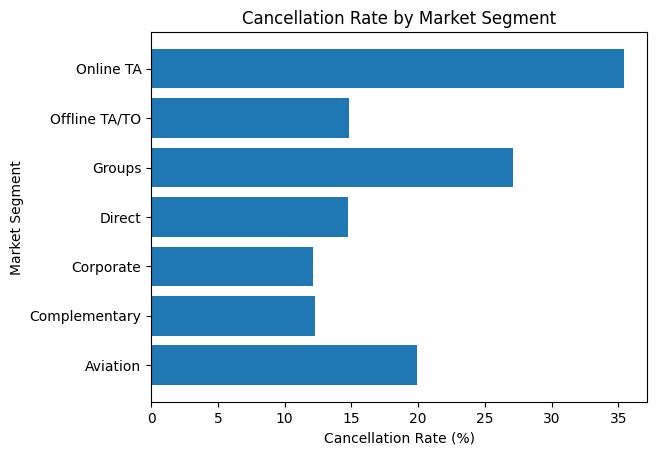

In [124]:
plt.barh(cancellation_by_segment.index, cancellation_by_segment.values)
plt.title("Cancellation Rate by Market Segment")
plt.xlabel("Cancellation Rate (%)")
plt.ylabel("Market Segment")
plt.show()

**Insight:** Online TA bookings had the highest cancellation rate at approximately 35.4%, followed by Groups at 27.1%. Corporate and Complementary bookings had the lowest cancellation rates, both around 12%. This indicates that cancellation rates vary considerably across market segments, with Online TA bookings showing the strongest association with cancellations.

### Question 8: How does cancellation rate vary by deposit type?

In [125]:
df["deposit_type"].value_counts()

deposit_type
No Deposit    86084
Non Refund     1038
Refundable      107
Name: count, dtype: int64

In [126]:
cancellation_by_deposit = df.groupby("deposit_type")["is_canceled"].mean() * 100
cancellation_by_deposit

deposit_type
No Deposit    26.718089
Non Refund    94.701349
Refundable    24.299065
Name: is_canceled, dtype: float64

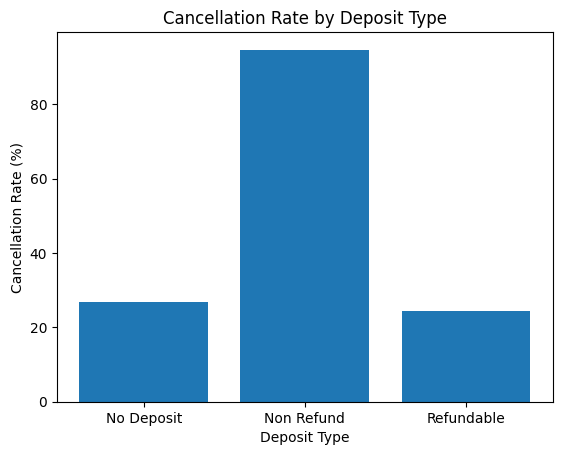

In [127]:
plt.bar(cancellation_by_deposit.index, cancellation_by_deposit.values)
plt.title("Cancellation Rate by Deposit Type")
plt.xlabel("Deposit Type")
plt.ylabel("Cancellation Rate (%)")
plt.show()

**Insight:** Non Refund bookings had a very high cancellation rate of approximately 94.7%, compared with 26.7% for No Deposit bookings and 24.3% for Refundable bookings. This shows a strong association between deposit type and cancellation behavior, with Non Refund bookings having a substantially higher cancellation rate than the other deposit types.

### Question 9: Is there a relationship between previous cancellations and current booking cancellation?

In [128]:
df["previous_cancellations"].value_counts().sort_index()

previous_cancellations
0     85548
1      1405
2       110
3        61
4        30
5        19
6        17
11       27
13        4
14        1
19        1
21        1
24        2
25        2
26        1
Name: count, dtype: int64

In [129]:
df[df["previous_cancellations"] == 0].groupby("is_canceled").size()

is_canceled
0    62682
1    22866
dtype: int64

In [130]:
df[df["previous_cancellations"] > 0].groupby("is_canceled").size()

is_canceled
0     538
1    1143
dtype: int64

In [131]:
cancellation_by_previous = df.groupby(df["previous_cancellations"] > 0)["is_canceled"].mean() * 100
cancellation_by_previous

previous_cancellations
False    26.728854
True     67.995241
Name: is_canceled, dtype: float64

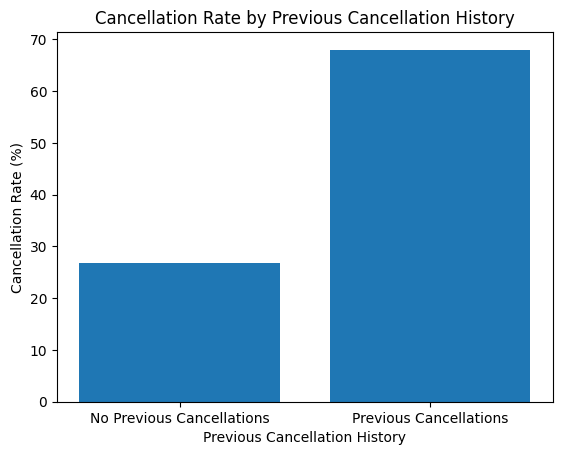

In [132]:
previous_labels = ["No Previous Cancellations", "Previous Cancellations"]

plt.bar(previous_labels, cancellation_by_previous.values)

plt.title("Cancellation Rate by Previous Cancellation History")
plt.xlabel("Previous Cancellation History")
plt.ylabel("Cancellation Rate (%)")

plt.show()

**Insight:** Bookings from customers with at least one previous cancellation had a much higher cancellation rate of approximately 68.0%, compared with 26.7% for customers with no previous cancellations. This indicates a strong association between previous cancellation history and the likelihood of cancelling a current booking.

### Question 10: Does cancellation rate differ between City Hotel and Resort Hotel?

In [133]:
cancellation_by_hotel = df.groupby("hotel")["is_canceled"].mean() * 100
cancellation_by_hotel

hotel
City Hotel      30.099110
Resort Hotel    23.484023
Name: is_canceled, dtype: float64

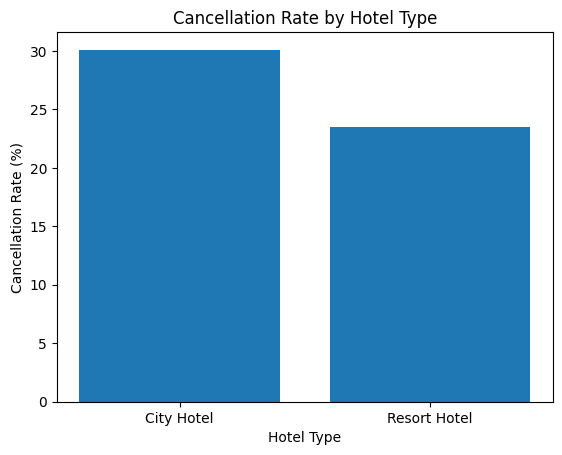

In [134]:
plt.bar(cancellation_by_hotel.index, cancellation_by_hotel.values)
plt.title("Cancellation Rate by Hotel Type")
plt.xlabel("Hotel Type")
plt.ylabel("Cancellation Rate (%)")
plt.show()

**Insight:** City Hotel bookings had a higher cancellation rate of approximately 30.1%, compared with 23.5% for Resort Hotel bookings. This indicates that City Hotel bookings were associated with a higher likelihood of cancellation than Resort Hotel bookings.

### Question 11: Which arrival months have the highest number of bookings?

In [135]:
df["arrival_date_month"].value_counts()

arrival_date_month
August       11242
July         10043
May           8344
April         7900
June          7756
March         7488
October       6921
September     6682
February      6083
December      5112
November      4973
January       4685
Name: count, dtype: int64

In [136]:
month_order = ["January", "February", "March", "April","May", "June", "July", "August","September", "October", "November", "December"]

In [137]:
monthly_bookings = df["arrival_date_month"].value_counts().reindex(month_order)
monthly_bookings

arrival_date_month
January       4685
February      6083
March         7488
April         7900
May           8344
June          7756
July         10043
August       11242
September     6682
October       6921
November      4973
December      5112
Name: count, dtype: int64

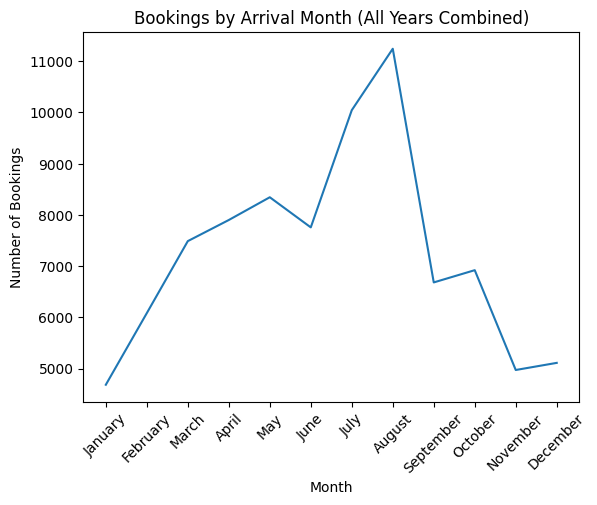

In [138]:
plt.plot(monthly_bookings.index, monthly_bookings.values)
plt.title("Bookings by Arrival Month (All Years Combined)")
plt.xlabel("Month")
plt.ylabel("Number of Bookings")
plt.xticks(rotation=45)
plt.show()

**Insight:** August recorded the highest number of bookings (11,242), while January recorded the lowest (4,685) across the combined dataset. Further year-wise analysis is needed to determine whether this pattern repeats consistently.

## Business Insights

The analysis revealed several important patterns in hotel booking behavior:

1. **Booking Distribution:** City Hotels accounted for approximately 61.1% of bookings, while Resort Hotels accounted for 38.9%.

2. **Cancellation Rate:** Approximately 27.5% of bookings were cancelled, indicating that cancellations were a significant factor in the dataset.

3. **Lead Time:** Cancelled bookings had a higher average lead time (approximately 106 days) than non-cancelled bookings (approximately 70 days).

4. **Market Segment:** Online TA bookings had the highest cancellation rate among the market segments analyzed, at approximately 35.4%.

5. **Deposit Type:** Non Refund bookings showed an unusually high cancellation rate of approximately 94.7%, compared with 26.7% for No Deposit bookings and 24.3% for Refundable bookings.

6. **Previous Cancellation History:** Bookings from customers with previous cancellations had a cancellation rate of approximately 68.0%, compared with 26.7% for customers with no previous cancellations.

7. **Hotel Type:** City Hotel bookings had a higher cancellation rate (30.1%) than Resort Hotel bookings (23.5%).

8. **Monthly Booking Pattern:** August recorded the highest number of bookings (11,242), while January recorded the lowest (4,685) across the combined dataset. Further year-wise analysis is needed to determine whether this pattern repeats consistently.

## Conclusion

This project analyzed hotel booking data to understand booking patterns, customer behavior, and factors associated with cancellations. The analysis found that approximately 27.5% of bookings were cancelled. Cancellation rates were higher among bookings with longer lead times, bookings from the Online TA market segment, bookings with a Non Refund deposit type, and bookings from customers with previous cancellations. City Hotels also had a higher cancellation rate than Resort Hotels.

The monthly analysis showed that August had the highest number of bookings, while January had the lowest in the combined dataset. Overall, this project demonstrates how Python, Pandas, and Matplotlib can be used to clean data, explore patterns, visualize results, and derive meaningful business insights. Further analysis could examine monthly patterns by year and investigate the factors associated with cancellations in greater detail.